# Energy Agency Data Loader

This notebook loads, processes, and interpolates the Swedish Energy Agency's future electricity demand data.

**Input:** `framtida-elbehov-pa-lansniva.xlsx` (Future electricity demand by county)

**Output:**
- `annual_demand.parquet` - Interpolated annual data (2025-2050)
- `raw_5year.parquet` - Original 5-year interval data

## 1. Setup & Configuration

In [ ]:
import pandas as pd
import numpy as np
import duckdb
from pathlib import Path
import matplotlib.pyplot as plt

# Configuration
DATA_PATH = Path('.')
EXCEL_FILE = DATA_PATH / 'framtida-elbehov-pa-lansniva.xlsx'
SHEET_NAME = 'Elbehov_Siffror'
TABLE_START_ROW = 2  # Tabell3 starts on row 2 (0-indexed: skiprows=1)

# Output file (DuckDB)
OUTPUT_DB = DATA_PATH / 'energy_agency.duckdb'

# Year range for interpolation
START_YEAR = 2025
END_YEAR = 2050

# County name to code mapping
COUNTY_CODE_MAP = {
    'Stockholms län': '01',
    'Uppsala län': '03',
    'Södermanlands län': '04',
    'Östergötlands län': '05',
    'Jönköpings län': '06',
    'Kronobergs län': '07',
    'Kalmar län': '08',
    'Gotlands län': '09',
    'Blekinge län': '10',
    'Skåne län': '12',
    'Hallands län': '13',
    'Västra Götalands län': '14',
    'Värmlands län': '17',
    'Örebro län': '18',
    'Västmanlands län': '19',
    'Dalarnas län': '20',
    'Gävleborgs län': '21',
    'Västernorrlands län': '22',
    'Jämtlands län': '23',
    'Västerbottens län': '24',
    'Norrbottens län': '25',
}

print(f"Excel file exists: {EXCEL_FILE.exists()}")
print(f"Output: {OUTPUT_DB}")

## 2. Load Excel Data

In [2]:
# Load the Excel file
# Skip first row (table header) to get to actual data
df_raw = pd.read_excel(
    EXCEL_FILE,
    sheet_name=SHEET_NAME,
    skiprows=1  # Skip the "Tabell3" header row
)

print(f"Loaded {len(df_raw)} rows")
print(f"\nColumns: {list(df_raw.columns)}")
df_raw.head(10)

Loaded 4914 rows

Columns: ['Scenario', 'Sektor nivå 1', 'Sektor nivå 2', 'År', 'Län', 'Elbehov (GWh)', 'Unnamed: 6', 'Sektor nivå 1.1', 'Sektor nivå 2.1', 'Unnamed: 9', 'Sektor nivå 1.2', 'Unnamed: 11', 'År.1', 'Unnamed: 13', 'Län.1', 'Unnamed: 15', 'Scenario.1']


,Scenario,Sektor nivå 1,Sektor nivå 2,År,Län,Elbehov (GWh),Unnamed: 6,Sektor nivå 1.1,Sektor nivå 2.1,Unnamed: 9,Sektor nivå 1.2,Unnamed: 11,År.1,Unnamed: 13,Län.1,Unnamed: 15,Scenario.1
0,Lokal Miljöhänsyn,Industri,Industri,2025,Blekinge län,534.0,NaN,Industri,Industri,NaN,Industri,NaN,2025.0,NaN,Blekinge län,NaN,Beslutad Policy
1,Lokal Miljöhänsyn,Industri,Industri,2030,Blekinge län,464.0,NaN,Inrikes transporter,"Vägtransporter, personbilar",NaN,Inrikes transporter,NaN,2030.0,NaN,Dalarnas län,NaN,Lokal Miljöhänsyn
2,Lokal Miljöhänsyn,Industri,Industri,2035,Blekinge län,422.0,NaN,Inrikes transporter,"Vägtransporter, tunga lastbilar",NaN,Bostäder,NaN,2035.0,NaN,Gävleborgs län,NaN,Internationell Tillväxt
3,Lokal Miljöhänsyn,Industri,Industri,2040,Blekinge län,400.0,NaN,Inrikes transporter,"Vägtransporter, lätta lastbilar",NaN,Service,NaN,2040.0,NaN,Jämtlands län,NaN,NaN
4,Lokal Miljöhänsyn,Industri,Industri,2045,Blekinge län,383.0,NaN,Inrikes transporter,"Vägtransporter, Bussar",NaN,Datahallar,NaN,2045.0,NaN,Jönköpings län,NaN,NaN
5,Lokal Miljöhänsyn,Industri,Industri,2050,Blekinge län,391.0,NaN,Inrikes transporter,Bantransport,NaN,NaN,NaN,2050.0,NaN,Kalmar län,NaN,NaN
6,Lokal Miljöhänsyn,Industri,Industri,2025,Dalarnas län,2220.0,NaN,Inrikes transporter,"Arbetsmaskiner, industri",NaN,NaN,NaN,NaN,NaN,Kronobergs län,NaN,NaN
7,Lokal Miljöhänsyn,Industri,Industri,2030,Dalarnas län,3287.0,NaN,Bostäder,"Småhus, elbaserad värme",NaN,NaN,NaN,NaN,NaN,Norrbottens län,NaN,NaN
8,Lokal Miljöhänsyn,Industri,Industri,2035,Dalarnas län,3253.0,NaN,Bostäder,"Flerbostadshus, elbaserad värme",NaN,NaN,NaN,NaN,NaN,Gotlands län,NaN,NaN
9,Lokal Miljöhänsyn,Industri,Industri,2040,Dalarnas län,3214.0,NaN,Bostäder,Hushåll och fastighetsel,NaN,NaN,NaN,NaN,NaN,Hallands län,NaN,NaN


In [3]:
# Rename columns to standard names
COLUMN_MAP = {
    'Scenario': 'scenario',
    'Sektor nivå 1': 'sector_level1',
    'Sektor nivå 2': 'sector_level2',
    'År': 'year',
    'Län': 'county_code',
    'Elbehov (GWh)': 'demand_gwh'
}

df = df_raw.rename(columns=COLUMN_MAP)
print("Renamed columns:")
print(list(df.columns))

Renamed columns:
['scenario', 'sector_level1', 'sector_level2', 'year', 'county_code', 'demand_gwh', 'Unnamed: 6', 'Sektor nivå 1.1', 'Sektor nivå 2.1', 'Unnamed: 9', 'Sektor nivå 1.2', 'Unnamed: 11', 'År.1', 'Unnamed: 13', 'Län.1', 'Unnamed: 15', 'Scenario.1']


## 3. Explore Data Structure

In [4]:
# List unique values for each dimension
print("=== SCENARIOS ===")
print(df['scenario'].unique())
print(f"Count: {df['scenario'].nunique()}")

print("\n=== SECTOR LEVEL 1 ===")
print(df['sector_level1'].unique())
print(f"Count: {df['sector_level1'].nunique()}")

print("\n=== SECTOR LEVEL 2 ===")
print(df['sector_level2'].unique())
print(f"Count: {df['sector_level2'].nunique()}")

print("\n=== YEARS ===")
print(sorted(df['year'].unique()))
print(f"Count: {df['year'].nunique()}")

print("\n=== COUNTIES ===")
print(sorted(df['county_code'].unique()))
print(f"Count: {df['county_code'].nunique()}")

=== SCENARIOS ===
['Lokal Miljöhänsyn' 'Internationell Tillväxt' 'Beslutad Policy']
Count: 3

=== SECTOR LEVEL 1 ===
['Industri' 'Datacenter' 'Bostäder' 'Service' 'Inrikes transporter']
Count: 5

=== SECTOR LEVEL 2 ===
['Industri' 'Datacenter' 'Småhus, elbaserad värme'
 'Flerbostadshus, elbaserad värme' 'Hushåll och fastighetsel'
 'Lokaler, elbaserad värme'
 'Driftel, service och Jordbruk, skogsbruk, fiske'
 'Vägtransporter, personbilar' 'Vägtransporter, tunga lastbilar'
 'Vägtransporter, lätta lastbilar' 'Bantransport'
 'Arbetsmaskiner, industri' 'Vägtransporter, Bussar']
Count: 13

=== YEARS ===
[np.int64(2025), np.int64(2030), np.int64(2035), np.int64(2040), np.int64(2045), np.int64(2050)]
Count: 6

=== COUNTIES ===
['Blekinge län', 'Dalarnas län', 'Gotlands län', 'Gävleborgs län', 'Hallands län', 'Jämtlands län', 'Jönköpings län', 'Kalmar län', 'Kronobergs län', 'Norrbottens län', 'Skåne län', 'Stockholms län', 'Södermanlands län', 'Uppsala län', 'Värmlands län', 'Västerbottens län

In [5]:
# Cross-tabulation of sector levels
print("=== SECTOR HIERARCHY ===")
sector_hierarchy = df.groupby(['sector_level1', 'sector_level2']).size().reset_index(name='count')
for level1 in df['sector_level1'].unique():
    print(f"\n{level1}:")
    level2_items = sector_hierarchy[sector_hierarchy['sector_level1'] == level1]['sector_level2'].tolist()
    for item in level2_items:
        print(f"  - {item}")

=== SECTOR HIERARCHY ===

Industri:
  - Industri

Datacenter:
  - Datacenter

Bostäder:
  - Flerbostadshus, elbaserad värme
  - Hushåll och fastighetsel
  - Småhus, elbaserad värme

Service:
  - Driftel, service och Jordbruk, skogsbruk, fiske
  - Lokaler, elbaserad värme

Inrikes transporter:
  - Arbetsmaskiner, industri
  - Bantransport
  - Vägtransporter, Bussar
  - Vägtransporter, lätta lastbilar
  - Vägtransporter, personbilar
  - Vägtransporter, tunga lastbilar


In [6]:
# Summary statistics
print("=== SUMMARY STATISTICS ===")
print(f"\nTotal rows: {len(df)}")
print(f"Expected rows: {df['scenario'].nunique()} scenarios × {df['sector_level2'].nunique()} sectors × {df['year'].nunique()} years × {df['county_code'].nunique()} counties")
expected = df['scenario'].nunique() * df['sector_level2'].nunique() * df['year'].nunique() * df['county_code'].nunique()
print(f"Expected: {expected}")

print(f"\nDemand range: {df['demand_gwh'].min():.2f} - {df['demand_gwh'].max():.2f} GWh")
print(f"Total demand (all scenarios, 2025): {df[df['year']==2025]['demand_gwh'].sum()/df['scenario'].nunique():.1f} GWh")

=== SUMMARY STATISTICS ===

Total rows: 4914
Expected rows: 3 scenarios × 13 sectors × 6 years × 21 counties
Expected: 4914

Demand range: 0.00 - 113760.00 GWh
Total demand (all scenarios, 2025): 128081.9 GWh


In [7]:
# Check for missing values
print("=== MISSING VALUES ===")
print(df.isnull().sum())

# Check for zeros or negative values
print(f"\nZero demand values: {(df['demand_gwh'] == 0).sum()}")
print(f"Negative demand values: {(df['demand_gwh'] < 0).sum()}")

=== MISSING VALUES ===
scenario              0
sector_level1         0
sector_level2         0
year                  0
county_code           0
demand_gwh            0
Unnamed: 6         4914
Sektor nivå 1.1    4901
Sektor nivå 2.1    4901
Unnamed: 9         4914
Sektor nivå 1.2    4909
Unnamed: 11        4914
År.1               4908
Unnamed: 13        4914
Län.1              4893
Unnamed: 15        4914
Scenario.1         4911
dtype: int64

Zero demand values: 128
Negative demand values: 0


## 4. Map Segments to Standard Names

Map Swedish segment names to standard generator segment names.

In [ ]:
# Define segment mapping based on user specification
# 
# Mapping rules:
#   industry       = Industri (Level 1) + Arbetsmaskiner, industri (Level 2)
#   datacenters    = Datacenter (Level 1)
#   housing        = Bostäder (Level 1)
#   services       = Service (Level 1)
#   transport_cars = Vägtransporter, personbilar (Level 2)
#   transport_trucks = Vägtransporter, tunga/lätta lastbilar + Bussar (Level 2)
#   transport_rail = Bantransport (Level 2)

SEGMENT_MAP = {
    # Industry: Industri (Level 1) + Arbetsmaskiner (industrial machines from transport)
    ('Industri', 'Industri'): 'industry',
    ('Inrikes transporter', 'Arbetsmaskiner, industri'): 'industry',
    
    # Datacenters: Level 1 category
    ('Datacenter', 'Datacenter'): 'datacenters',
    
    # Housing: All Bostäder subcategories
    ('Bostäder', 'Småhus, elbaserad värme'): 'housing',
    ('Bostäder', 'Flerbostadshus, elbaserad värme'): 'housing',
    ('Bostäder', 'Hushåll och fastighetsel'): 'housing',
    
    # Services: All Service subcategories
    ('Service', 'Lokaler, elbaserad värme'): 'services',
    ('Service', 'Driftel, service och Jordbruk, skogsbruk, fiske'): 'services',
    
    # Transport - Cars
    ('Inrikes transporter', 'Vägtransporter, personbilar'): 'transport_cars',
    
    # Transport - Trucks (heavy, light, and buses)
    ('Inrikes transporter', 'Vägtransporter, tunga lastbilar'): 'transport_trucks',
    ('Inrikes transporter', 'Vägtransporter, lätta lastbilar'): 'transport_trucks',
    ('Inrikes transporter', 'Vägtransporter, Bussar'): 'transport_trucks',
    
    # Transport - Rail
    ('Inrikes transporter', 'Bantransport'): 'transport_rail',
}

# Apply mapping
def map_segment(row):
    key = (row['sector_level1'], row['sector_level2'])
    return SEGMENT_MAP.get(key, 'unmapped')

df['segment'] = df.apply(map_segment, axis=1)

# Show mapping results
print("=== SEGMENT MAPPING ===")
mapping_check = df.groupby(['sector_level1', 'sector_level2', 'segment']).size().reset_index(name='count')
print(mapping_check.to_string(index=False))

# Check for unmapped
unmapped = df[df['segment'] == 'unmapped']
if len(unmapped) > 0:
    print(f"\nWARNING: {len(unmapped)} unmapped rows!")
    print(unmapped[['sector_level1', 'sector_level2']].drop_duplicates())
else:
    print("\n✓ All segments mapped successfully!")

In [9]:
# Check for unmapped segments
unmapped = df[df['segment'] == 'other']
if len(unmapped) > 0:
    print("WARNING: Unmapped segments found!")
    print(unmapped[['sector_level1', 'sector_level2']].drop_duplicates())
else:
    print("All segments mapped successfully!")

            sector_level1                                    sector_level2
126            Datacenter                                       Datacenter
252              Bostäder                          Småhus, elbaserad värme
378              Bostäder                  Flerbostadshus, elbaserad värme
504              Bostäder                         Hushåll och fastighetsel
630               Service                         Lokaler, elbaserad värme
756               Service  Driftel, service och Jordbruk, skogsbruk, fiske
882   Inrikes transporter                      Vägtransporter, personbilar
1008  Inrikes transporter                  Vägtransporter, tunga lastbilar
1134  Inrikes transporter                  Vägtransporter, lätta lastbilar
1260  Inrikes transporter                                     Bantransport
1386  Inrikes transporter                         Arbetsmaskiner, industri
1512  Inrikes transporter                           Vägtransporter, Bussar


In [ ]:
# Convert county names to codes using the mapping
df['geography'] = df['county_code'].map(COUNTY_CODE_MAP)

# Check for unmapped counties
unmapped_counties = df[df['geography'].isna()]['county_code'].unique()
if len(unmapped_counties) > 0:
    print(f"WARNING: Unmapped counties: {unmapped_counties}")
else:
    print("✓ All counties mapped to codes")

# Aggregate by segment (combine sub-segments)
df_agg = df.groupby(['scenario', 'segment', 'year', 'geography'])['demand_gwh'].sum().reset_index()
df_agg = df_agg.rename(columns={'demand_gwh': 'value'})

print(f"\nAggregated to {len(df_agg)} rows")
print(f"Unique segments: {sorted(df_agg['segment'].unique())}")
print(f"Unique geographies: {sorted(df_agg['geography'].unique())}")
df_agg.head(10)

## 5. Validate Raw Data

In [11]:
# Check that all combinations exist
scenarios = df_agg['scenario'].unique()
segments = df_agg['segment'].unique()
years = df_agg['year'].unique()
geographies = df_agg['geography'].unique()

expected_combinations = len(scenarios) * len(segments) * len(years) * len(geographies)
actual_combinations = len(df_agg)

print(f"Expected combinations: {expected_combinations}")
print(f"Actual combinations: {actual_combinations}")

if expected_combinations != actual_combinations:
    print("\nWARNING: Missing combinations!")
    # Find missing
    from itertools import product
    all_combos = set(product(scenarios, segments, years, geographies))
    existing = set(zip(df_agg['scenario'], df_agg['segment'], df_agg['year'], df_agg['geography']))
    missing = all_combos - existing
    print(f"Missing: {len(missing)} combinations")
    if len(missing) <= 20:
        for m in sorted(missing):
            print(f"  {m}")
else:
    print("All combinations present!")

Expected combinations: 756
Actual combinations: 756
All combinations present!


In [12]:
# Validate value ranges by segment
print("=== VALUE RANGES BY SEGMENT ===")
for seg in sorted(df_agg['segment'].unique()):
    seg_data = df_agg[df_agg['segment'] == seg]['value']
    print(f"{seg:20s}: min={seg_data.min():8.2f}, max={seg_data.max():8.2f}, mean={seg_data.mean():8.2f} GWh")

=== VALUE RANGES BY SEGMENT ===
industry            : min=  134.00, max=113760.00, mean= 5032.64 GWh
other               : min=  578.81, max=24455.65, mean= 4620.43 GWh


## 6. Interpolate to Annual Data

Interpolate from 5-year intervals (2025, 2030, 2035, 2040, 2045, 2050) to annual data.

In [13]:
def interpolate_to_annual(df_5year, start_year=2025, end_year=2050):
    """
    Interpolate 5-year data to annual values.
    
    Uses linear interpolation between known points.
    Each group (scenario, segment, geography) is interpolated independently.
    """
    results = []
    all_years = list(range(start_year, end_year + 1))
    
    # Group by everything except year and value
    groups = df_5year.groupby(['scenario', 'segment', 'geography'])
    
    for (scenario, segment, geography), group in groups:
        # Sort by year
        group = group.sort_values('year')
        
        # Create interpolation function
        known_years = group['year'].values
        known_values = group['value'].values
        
        # Linear interpolation
        interpolated_values = np.interp(all_years, known_years, known_values)
        
        # Create rows for each year
        for year, value in zip(all_years, interpolated_values):
            results.append({
                'scenario': scenario,
                'segment': segment,
                'geography': geography,
                'year': year,
                'value': value
            })
    
    return pd.DataFrame(results)

# Perform interpolation
df_annual = interpolate_to_annual(df_agg, START_YEAR, END_YEAR)

print(f"Interpolated from {len(df_agg)} to {len(df_annual)} rows")
print(f"Years: {df_annual['year'].min()} - {df_annual['year'].max()}")
df_annual.head(10)

Interpolated from 756 to 3276 rows
Years: 2025 - 2050


,scenario,segment,geography,year,value
0,Beslutad Policy,industry,Blekinge län,2025,538.0
1,Beslutad Policy,industry,Blekinge län,2026,531.8
2,Beslutad Policy,industry,Blekinge län,2027,525.6
3,Beslutad Policy,industry,Blekinge län,2028,519.4
4,Beslutad Policy,industry,Blekinge län,2029,513.2
5,Beslutad Policy,industry,Blekinge län,2030,507.0
6,Beslutad Policy,industry,Blekinge län,2031,507.0
7,Beslutad Policy,industry,Blekinge län,2032,507.0
8,Beslutad Policy,industry,Blekinge län,2033,507.0
9,Beslutad Policy,industry,Blekinge län,2034,507.0


In [14]:
# Validate: Check that interpolated values at source years match original
print("=== VALIDATION: Interpolated vs Original ===")
source_years = [2025, 2030, 2035, 2040, 2045, 2050]

for year in source_years:
    original = df_agg[df_agg['year'] == year]['value'].sum()
    interpolated = df_annual[df_annual['year'] == year]['value'].sum()
    diff = abs(original - interpolated)
    pct = diff / original * 100 if original > 0 else 0
    status = "✓" if pct < 0.01 else "✗"
    print(f"{year}: Original={original:.2f}, Interpolated={interpolated:.2f}, Diff={diff:.4f} ({pct:.4f}%) {status}")

=== VALIDATION: Interpolated vs Original ===
2025: Original=384245.64, Interpolated=384245.64, Diff=0.0000 (0.0000%) ✓
2030: Original=470654.69, Interpolated=470654.69, Diff=0.0000 (0.0000%) ✓
2035: Original=569033.47, Interpolated=569033.47, Diff=0.0000 (0.0000%) ✓
2040: Original=666227.24, Interpolated=666227.24, Diff=0.0000 (0.0000%) ✓
2045: Original=742716.27, Interpolated=742716.27, Diff=0.0000 (0.0000%) ✓
2050: Original=815981.74, Interpolated=815981.74, Diff=0.0000 (0.0000%) ✓


## 7. Visualize

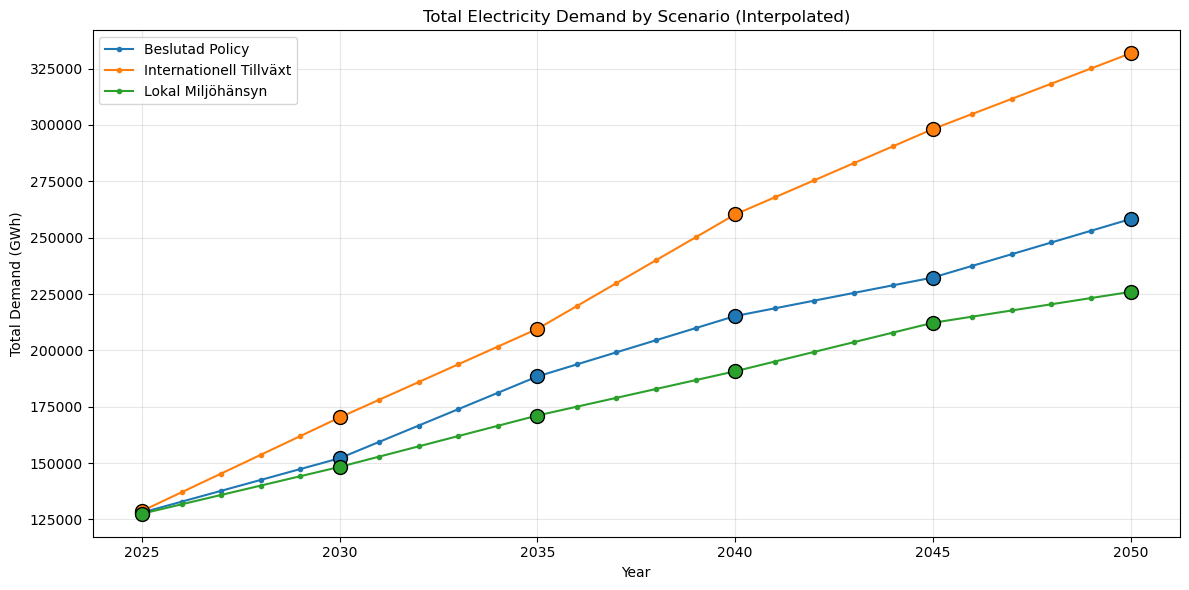

In [15]:
# Total demand by scenario (interpolated)
fig, ax = plt.subplots(figsize=(12, 6))

for scenario in df_annual['scenario'].unique():
    scenario_data = df_annual[df_annual['scenario'] == scenario]
    yearly_total = scenario_data.groupby('year')['value'].sum()
    ax.plot(yearly_total.index, yearly_total.values, marker='o', markersize=3, label=scenario)

# Mark original data points
source_years = [2025, 2030, 2035, 2040, 2045, 2050]
for scenario in df_annual['scenario'].unique():
    scenario_data = df_annual[df_annual['scenario'] == scenario]
    yearly_total = scenario_data.groupby('year')['value'].sum()
    ax.scatter([y for y in source_years], 
               [yearly_total[y] for y in source_years],
               s=100, zorder=5, edgecolor='black', linewidth=1)

ax.set_xlabel('Year')
ax.set_ylabel('Total Demand (GWh)')
ax.set_title('Total Electricity Demand by Scenario (Interpolated)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

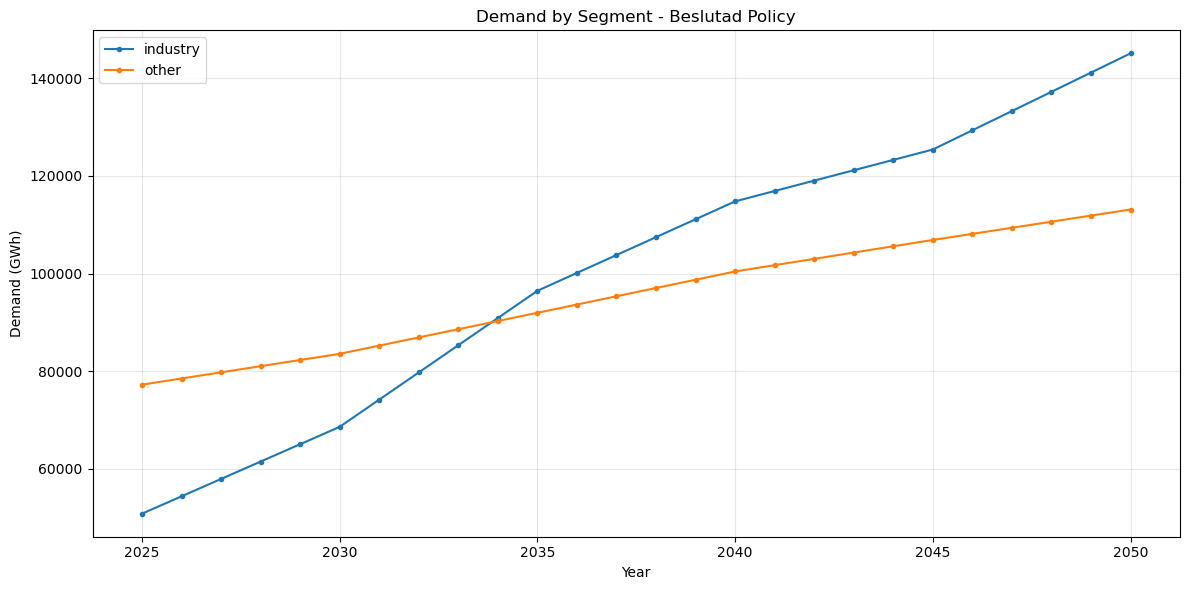

In [16]:
# Demand by segment for first scenario
first_scenario = df_annual['scenario'].unique()[0]
scenario_data = df_annual[df_annual['scenario'] == first_scenario]

fig, ax = plt.subplots(figsize=(12, 6))

for segment in sorted(scenario_data['segment'].unique()):
    seg_data = scenario_data[scenario_data['segment'] == segment]
    yearly_total = seg_data.groupby('year')['value'].sum()
    ax.plot(yearly_total.index, yearly_total.values, marker='o', markersize=3, label=segment)

ax.set_xlabel('Year')
ax.set_ylabel('Demand (GWh)')
ax.set_title(f'Demand by Segment - {first_scenario}')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

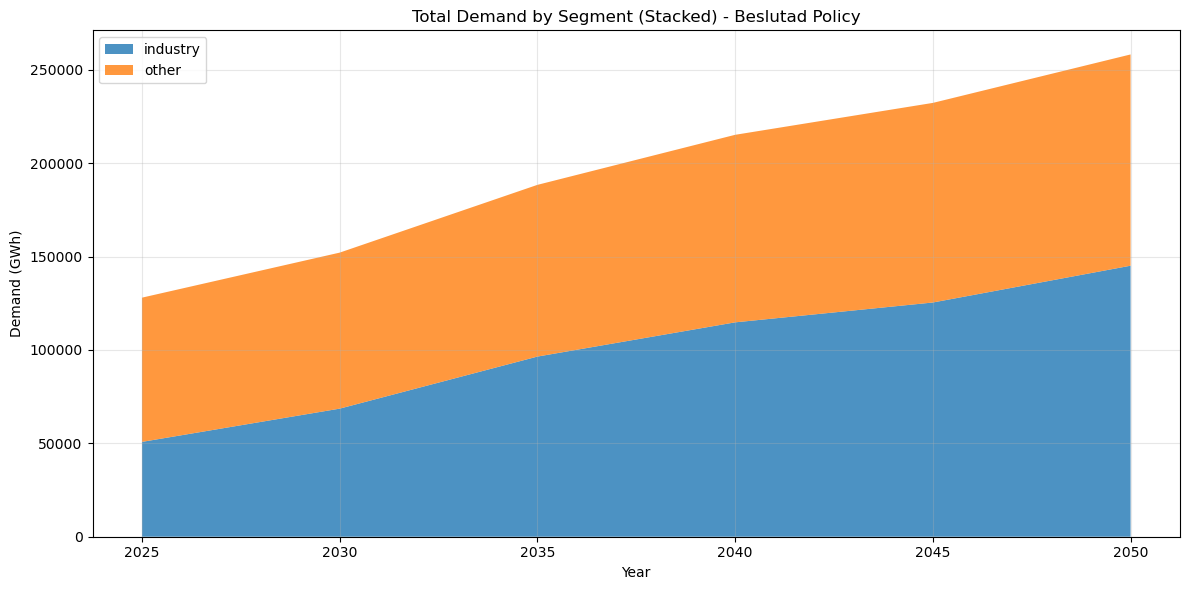

In [17]:
# Stacked area chart by segment
fig, ax = plt.subplots(figsize=(12, 6))

# Pivot for stacked area
pivot_data = scenario_data.groupby(['year', 'segment'])['value'].sum().unstack(fill_value=0)

# Sort segments by total demand
segment_order = pivot_data.sum().sort_values(ascending=False).index
pivot_data = pivot_data[segment_order]

ax.stackplot(pivot_data.index, pivot_data.T.values, labels=pivot_data.columns, alpha=0.8)

ax.set_xlabel('Year')
ax.set_ylabel('Demand (GWh)')
ax.set_title(f'Total Demand by Segment (Stacked) - {first_scenario}')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

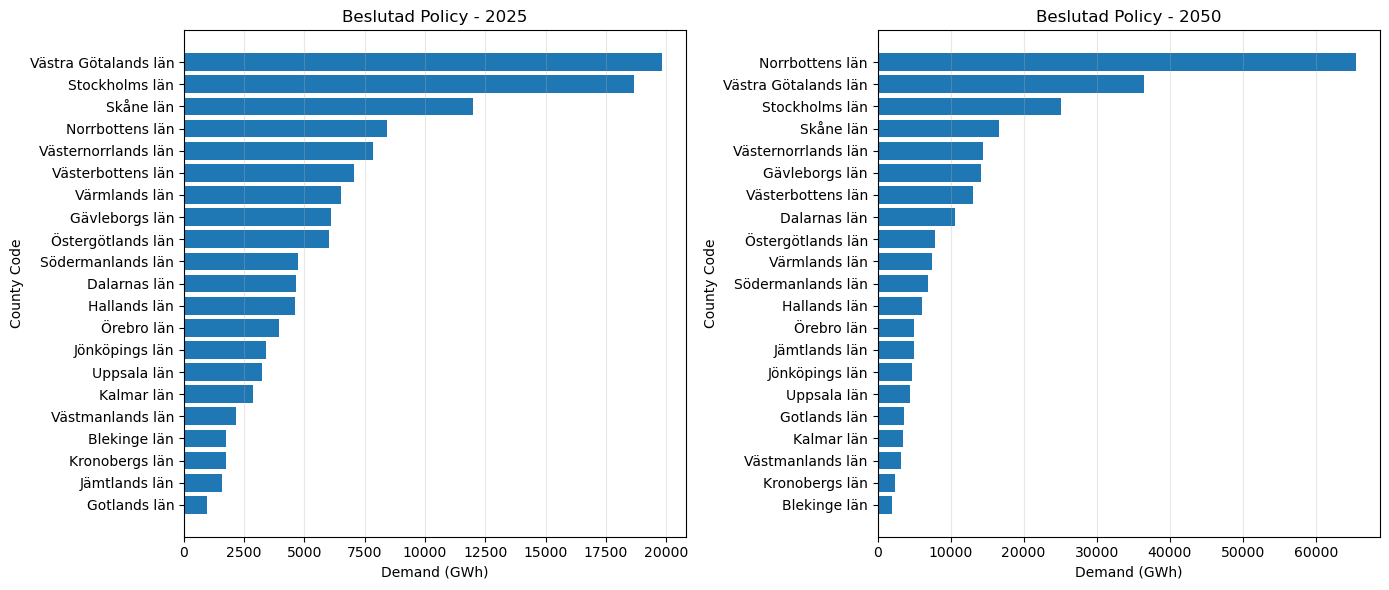

In [18]:
# Geographic distribution (2025 vs 2050)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, year in enumerate([2025, 2050]):
    year_data = scenario_data[scenario_data['year'] == year]
    geo_total = year_data.groupby('geography')['value'].sum().sort_values(ascending=True)
    
    axes[i].barh(geo_total.index, geo_total.values)
    axes[i].set_xlabel('Demand (GWh)')
    axes[i].set_ylabel('County Code')
    axes[i].set_title(f'{first_scenario} - {year}')
    axes[i].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [19]:
# Growth rates by segment
print("=== GROWTH RATES (2025 → 2050) ===")
for segment in sorted(scenario_data['segment'].unique()):
    seg_data = scenario_data[scenario_data['segment'] == segment]
    val_2025 = seg_data[seg_data['year'] == 2025]['value'].sum()
    val_2050 = seg_data[seg_data['year'] == 2050]['value'].sum()
    growth = (val_2050 - val_2025) / val_2025 * 100 if val_2025 > 0 else 0
    cagr = ((val_2050 / val_2025) ** (1/25) - 1) * 100 if val_2025 > 0 else 0
    print(f"{segment:20s}: {val_2025:8.1f} → {val_2050:8.1f} GWh ({growth:+6.1f}%, CAGR: {cagr:+.2f}%)")

=== GROWTH RATES (2025 → 2050) ===
industry            :  50786.0 → 145128.0 GWh (+185.8%, CAGR: +4.29%)
other               :  77230.0 → 113126.3 GWh ( +46.5%, CAGR: +1.54%)


## 8. Export

In [ ]:
# Final column order and types
df_annual_export = df_annual[['scenario', 'segment', 'year', 'geography', 'value']].copy()
df_annual_export['year'] = df_annual_export['year'].astype(int)
df_annual_export['value'] = df_annual_export['value'].astype(float)

print("=== ANNUAL DEMAND DATA ===")
print(f"Rows: {len(df_annual_export)}")
print(f"Columns: {list(df_annual_export.columns)}")
print(f"\nData types:")
print(df_annual_export.dtypes)
print(f"\nSegments: {sorted(df_annual_export['segment'].unique())}")
print(f"\nSample:")
df_annual_export.sample(10)

In [ ]:
# Export to DuckDB
# Remove existing file if present
if OUTPUT_DB.exists():
    OUTPUT_DB.unlink()

# Create DuckDB database with two tables
con = duckdb.connect(str(OUTPUT_DB))

# Create annual_demand table (interpolated data)
con.execute("""
    CREATE TABLE annual_demand AS 
    SELECT * FROM df_annual_export
""")

# Create raw_5year table (original data)
df_raw_export = df_agg[['scenario', 'segment', 'year', 'geography', 'value']].copy()
df_raw_export['year'] = df_raw_export['year'].astype(int)
df_raw_export['value'] = df_raw_export['value'].astype(float)

con.execute("""
    CREATE TABLE raw_5year AS 
    SELECT * FROM df_raw_export
""")

# Verify tables
print("=== DUCKDB TABLES ===")
tables = con.execute("SHOW TABLES").fetchall()
for table in tables:
    table_name = table[0]
    count = con.execute(f"SELECT COUNT(*) FROM {table_name}").fetchone()[0]
    print(f"  {table_name}: {count} rows")

con.close()
print(f"\nSaved: {OUTPUT_DB}")
print(f"Size: {OUTPUT_DB.stat().st_size / 1024:.1f} KB")

In [ ]:
# Summary
print("="*60)
print("EXPORT COMPLETE")
print("="*60)
print(f"\nDatabase: {OUTPUT_DB}")
print(f"\nTables:")
print(f"  1. annual_demand - {len(df_annual_export)} rows")
print(f"     - Years: {START_YEAR}-{END_YEAR} (annual, interpolated)")
print(f"     - Scenarios: {df_annual_export['scenario'].nunique()}")
print(f"     - Segments: {sorted(df_annual_export['segment'].unique())}")
print(f"     - Geographies: {df_annual_export['geography'].nunique()} counties")
print(f"\n  2. raw_5year - {len(df_raw_export)} rows")
print(f"     - Original Energy Agency 5-year data")

print("\n" + "="*60)
print("SEGMENT MAPPING SUMMARY")
print("="*60)
for seg in sorted(df_annual_export['segment'].unique()):
    seg_data = df_annual_export[df_annual_export['segment'] == seg]
    val_2025 = seg_data[seg_data['year'] == 2025]['value'].sum() / 3  # Per scenario avg
    val_2050 = seg_data[seg_data['year'] == 2050]['value'].sum() / 3
    growth = (val_2050 - val_2025) / val_2025 * 100 if val_2025 > 0 else 0
    print(f"  {seg:18s}: {val_2025:8.1f} → {val_2050:8.1f} GWh/yr ({growth:+6.1f}%)")